# Deep Learning Assignment 01 — Facial Expression (8‑way) + Valence/Arousal (Regression)

This notebook implements a **modular CNN pipeline** in **PyTorch** that:
- Trains **two CNN baselines** (ResNet‑18, EfficientNet‑B0) with a **multi‑task head**:
  - **Classification**: 8 expressions (0–7)
  - **Regression**: **Valence** and **Arousal** in [-1, 1]
- Computes all **required metrics**:
  - Classification: **Accuracy, F1, Cohen’s Kappa, AUC (ROC), AUC‑PR**
  - Regression: **RMSE, Pearson CORR, SAGR, CCC**
- Produces **training curves**, **quantitative comparison**, and a few **qualitative examples**.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install -q torch torchvision torchaudio torchmetrics scikit-learn matplotlib seaborn pandas numpy tqdm

In [6]:
# If running locally for the first time, uncomment to install dependencies:

import os, sys, math, random, json, shutil, zipfile, time
from pathlib import Path
from typing import Tuple, Dict, Any, List

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
from scipy.stats import pearsonr
from tqdm import tqdm

import torchmetrics
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

In [7]:
# =======================
# Configuration
# =======================
CFG = {
    "seed": 42,
    "img_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "epochs": 25,              # Increase to 25–50 for final runs
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "train_split": 0.8,        # 80/20 train/val
    "model_names": ["resnet18", "efficientnet_b0"],
    "early_stopping_patience": 5,
    "output_dir": "./outputs",
    "zip_path": "/content/drive/MyDrive/DL_Assignment1_Dataset.zip",  # Update if different
    "extract_root": "./data_faces"
}

os.makedirs(CFG["output_dir"], exist_ok=True)
random.seed(CFG["seed"]); np.random.seed(CFG["seed"]); torch.manual_seed(CFG["seed"]); torch.cuda.manual_seed_all(CFG["seed"])

## 1) Load & Index the Dataset

In [8]:
def ensure_extracted(zip_path: str, extract_root: str) -> Path:
    extract_root = Path(extract_root)
    if not extract_root.exists():
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_root)
    else:
        print("Using already-extracted dataset.")
    return extract_root

data_root = ensure_extracted(CFG["zip_path"], CFG["extract_root"])
# Find root inside the extracted structure
# We expect ".../Dataset/Dataset/images" and ".../Dataset/Dataset/annotations"
images_dir = next((p for p in data_root.rglob("images") if p.is_dir()), None)
ann_dir    = next((p for p in data_root.rglob("annotations") if p.is_dir()), None)
assert images_dir and ann_dir, f"Could not locate images or annotations under {data_root}"

# Build index of (id -> image path and annotation files)
image_files = sorted(images_dir.glob("*.jpg"))
len(image_files), image_files[:5]

Extracting dataset...


(3999,
 [PosixPath('data_faces/Dataset/Dataset/images/0.jpg'),
  PosixPath('data_faces/Dataset/Dataset/images/1.jpg'),
  PosixPath('data_faces/Dataset/Dataset/images/10.jpg'),
  PosixPath('data_faces/Dataset/Dataset/images/100.jpg'),
  PosixPath('data_faces/Dataset/Dataset/images/1001.jpg')])

In [9]:
def load_npy(path: Path):
    # The distributed .npy store strings for scalars; cast properly.
    arr = np.load(path, allow_pickle=True)
    if isinstance(arr, np.ndarray) and arr.shape == ():
        v = arr.item()
        try:
            if "." in v or "e" in v or "-" in v or "+" in v:
                return float(v)
            else:
                return int(v)
        except Exception:
            return v
    return arr

def read_annotation(ann_dir: Path, img_id: int) -> Dict[str, Any]:
    d = {}
    d["exp"] = load_npy(ann_dir / f"{img_id}_exp.npy")   # str-number -> int
    d["aro"] = load_npy(ann_dir / f"{img_id}_aro.npy")   # str-number -> float
    d["val"] = load_npy(ann_dir / f"{img_id}_val.npy")   # str-number -> float
    lnd_arr = np.array(load_npy(ann_dir / f"{img_id}_lnd.npy"), dtype=np.float32)
    if lnd_arr.ndim == 1 and lnd_arr.size == 136:
        d["lnd"] = lnd_arr.reshape(68, 2)
    else:
        d["lnd"] = lnd_arr
    # Cast
    d["exp"] = int(d["exp"])
    d["aro"] = float(d["aro"])
    d["val"] = float(d["val"])
    return d

# Quick sanity check on a couple of samples
sample_meta = [read_annotation(ann_dir, int(p.stem)) for p in image_files[:3]]
sample_meta

[{'exp': 0,
  'aro': -0.0776398,
  'val': -0.176846,
  'lnd': array([[-6.66666683e-03,  8.14980087e+01],
         [ 2.80999994e+00,  1.07939178e+02],
         [ 8.13666630e+00,  1.34373795e+02],
         [ 1.53233337e+01,  1.58335907e+02],
         [ 2.76100006e+01,  1.80454269e+02],
         [ 4.71566658e+01,  1.98033691e+02],
         [ 6.91699982e+01,  2.11663620e+02],
         [ 9.08000031e+01,  2.21347366e+02],
         [ 1.11949997e+02,  2.24602570e+02],
         [ 1.32963333e+02,  2.21380112e+02],
         [ 1.53270004e+02,  2.10749939e+02],
         [ 1.72553329e+02,  1.97293564e+02],
         [ 1.91013336e+02,  1.81544800e+02],
         [ 2.02653336e+02,  1.60559525e+02],
         [ 2.09523331e+02,  1.36106201e+02],
         [ 2.14586670e+02,  1.08826668e+02],
         [ 2.16303329e+02,  7.93169556e+01],
         [ 1.65166664e+01,  6.81300583e+01],
         [ 3.25433350e+01,  5.78863144e+01],
         [ 5.25433350e+01,  5.68449135e+01],
         [ 7.39066696e+01,  6.00149689e+

## 2) PyTorch Dataset

In [10]:
class FacialAffectDataset(Dataset):
    CLASSES = ["Neutral","Happy","Sad","Surprise","Fear","Disgust","Anger","Contempt"]
    NUM_CLASSES = 8

    def __init__(self, images_dir: Path, ann_dir: Path, indices: List[int], train: bool=True, img_size: int=224):
        self.images = sorted(images_dir.glob("*.jpg"))
        self.ann_dir = Path(ann_dir)
        self.idxs = indices
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]
        if train:
            self.tfms = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])
        else:
            self.tfms = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i: int):
        idx = self.idxs[i]
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        img_id = int(img_path.stem)
        ann = read_annotation(self.ann_dir, img_id)
        x = self.tfms(img)
        y_cls = torch.tensor(ann["exp"], dtype=torch.long)
        y_reg = torch.tensor([ann["val"], ann["aro"]], dtype=torch.float32)  # [valence, arousal]
        return x, y_cls, y_reg, img_path.as_posix()

## 3) Split Train/Val and Build DataLoaders

In [11]:
N = len(list(images_dir.glob("*.jpg")))
indices = list(range(N))
random.shuffle(indices)

n_train = int(CFG["train_split"] * N)
train_indices = indices[:n_train]
val_indices   = indices[n_train:]

ds_train = FacialAffectDataset(images_dir, ann_dir, train_indices, train=True,  img_size=CFG["img_size"])
ds_val   = FacialAffectDataset(images_dir, ann_dir, val_indices,   train=False, img_size=CFG["img_size"])

dl_train = DataLoader(ds_train, batch_size=CFG["batch_size"], shuffle=True,  num_workers=CFG["num_workers"], pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=True)

len(ds_train), len(ds_val)

(3199, 800)

## 4) Models — ResNet‑18 & EfficientNet‑B0 (with a Multi‑Task Head)

In [12]:
class MultiTaskHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int=8):
        super().__init__()
        self.dropout = nn.Dropout(0.2)
        self.cls_head = nn.Linear(in_features, num_classes)
        self.reg_head = nn.Linear(in_features, 2)  # [valence, arousal]

    def forward(self, feats):
        feats = self.dropout(feats)
        logits = self.cls_head(feats)
        regs   = torch.tanh(self.reg_head(feats))  # in [-1,1]
        return logits, regs

def build_model(name: str, num_classes: int=8):
    name = name.lower()
    if name == "resnet18":
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_feats = backbone.fc.in_features
        backbone.fc = nn.Identity()
    elif name == "efficientnet_b0":
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_feats = backbone.classifier[-1].in_features
        backbone.classifier = nn.Identity()
    else:
        raise ValueError(f"Unknown model: {name}")
    head = MultiTaskHead(in_feats, num_classes)
    model = nn.Sequential(backbone, head)
    return model

# Quick forward check
tmp = build_model("resnet18").to(DEVICE)
x = torch.randn(2,3,CFG["img_size"],CFG["img_size"]).to(DEVICE)
with torch.no_grad():
    logits, regs = tmp(x)
logits.shape, regs.shape

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 60.5MB/s]


(torch.Size([2, 8]), torch.Size([2, 2]))

## 5) Losses & Metrics

In [13]:
ce_loss  = nn.CrossEntropyLoss()
l1_loss  = nn.SmoothL1Loss(beta=0.1)  # robust for [-1,1]

def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    # y_* shape: (N, 2) -> [val, aro]
    def rmse(a,b): return float(np.sqrt(np.mean((a-b)**2)))
    def corr(a,b):
        if a.std() == 0 or b.std() == 0: return 0.0
        return float(pearsonr(a,b)[0])
    # SAGR: sign agreement rate over both dims averaged
    def sagr(a,b):
        return float(((np.sign(a)==np.sign(b)).mean()))
    # Lin's Concordance Correlation Coefficient per dim then mean
    def ccc(a,b):
        mu_a, mu_b = a.mean(), b.mean()
        var_a, var_b = a.var(), b.var()
        cov = np.mean((a-mu_a)*(b-mu_b))
        return float((2*cov) / (var_a + var_b + (mu_a - mu_b)**2 + 1e-8))

    out = {}
    for i, name in enumerate(["valence","arousal"]):
        a = y_true[:,i]; b = y_pred[:,i]
        out[f"RMSE_{name}"] = rmse(a,b)
        out[f"CORR_{name}"] = corr(a,b)
        out[f"CCC_{name}"]  = ccc(a,b)
        out[f"SAGR_{name}"] = sagr(a,b)
    # macro averages
    out["RMSE_mean"] = np.mean([out["RMSE_valence"], out["RMSE_arousal"]]).item()
    out["CORR_mean"] = np.mean([out["CORR_valence"], out["CORR_arousal"]]).item()
    out["CCC_mean"]  = np.mean([out["CCC_valence"],  out["CCC_arousal"] ]).item()
    out["SAGR_mean"] = np.mean([out["SAGR_valence"], out["SAGR_arousal"]]).item()
    return out

def classification_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    y_pred = y_prob.argmax(axis=1)
    out = {}
    out["Accuracy"] = accuracy_score(y_true, y_pred)
    out["F1_macro"] = f1_score(y_true, y_pred, average="macro")
    out["Kappa"]    = cohen_kappa_score(y_true, y_pred)
    # AUC and PR need one-vs-rest probabilities; may fail if a class missing in y_true
    try:
        out["AUC_macro_ovr"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        out["AUC_macro_ovr"] = float("nan")
    try:
        aps = []
        for c in range(y_prob.shape[1]):
            aps.append(average_precision_score((y_true==c).astype(int), y_prob[:,c]))
        out["AUC_PR_macro"] = float(np.nanmean(aps))
    except Exception:
        out["AUC_PR_macro"] = float("nan")
    return out

## 6) Train/Evaluate Utilities

In [14]:
def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc="Train", leave=False)
    for x, y_cls, y_reg, _ in pbar:
        x, y_cls, y_reg = x.to(DEVICE), y_cls.to(DEVICE), y_reg.to(DEVICE)
        optimizer.zero_grad()
        logits, regs = model(x)
        loss = ce_loss(logits, y_cls) + l1_loss(regs, y_reg)
        loss.backward()
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * x.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_yc = []
    all_yr = []
    all_pr = []
    for x, y_cls, y_reg, _ in loader:
        x, y_cls, y_reg = x.to(DEVICE), y_cls.to(DEVICE), y_reg.to(DEVICE)
        logits, regs = model(x)
        loss = ce_loss(logits, y_cls) + l1_loss(regs, y_reg)
        total_loss += loss.item() * x.size(0)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_yc.append(y_cls.cpu().numpy())
        all_yr.append(y_reg.cpu().numpy())
        all_pr.append(regs.detach().cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    y_prob = np.concatenate(all_probs, axis=0)
    y_cls  = np.concatenate(all_yc, axis=0)
    y_true = np.concatenate(all_yr, axis=0)
    y_pred = np.concatenate(all_pr, axis=0)
    cls_metrics = classification_metrics(y_cls, y_prob)
    reg_metrics = regression_metrics(y_true, y_pred)
    return avg_loss, cls_metrics, reg_metrics

def fit_model(model_name: str):
    model = build_model(model_name).to(DEVICE)
    # Optionally freeze early layers for a few epochs (transfer learning warmup)
    # for p in list(model[0].parameters())[:-10]: p.requires_grad = False

    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0= len(dl_train), T_mult=2)

    history = {"train_loss": [], "val_loss": [], "val_cls": [], "val_reg": []}
    best_val = float("inf"); best_path = Path(CFG["output_dir"]) / f"best_{model_name}.pt"
    patience = CFG["early_stopping_patience"]; bad = 0

    for epoch in range(1, CFG["epochs"]+1):
        print(f"\n[{model_name}] Epoch {epoch}/{CFG['epochs']}")
        tr_loss = train_one_epoch(model, dl_train, optimizer, scheduler)
        val_loss, cls_m, reg_m = evaluate(model, dl_val)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_cls"].append(cls_m)
        history["val_reg"].append(reg_m)

        print(f"  train_loss: {tr_loss:.4f} | val_loss: {val_loss:.4f}")
        print(f"  Acc: {cls_m['Accuracy']:.3f} | F1: {cls_m['F1_macro']:.3f} | Kappa: {cls_m['Kappa']:.3f} | AUC: {cls_m['AUC_macro_ovr']:.3f} | AUC_PR: {cls_m['AUC_PR_macro']:.3f}")
        print(f"  RMSE_mean: {reg_m['RMSE_mean']:.3f} | CORR_mean: {reg_m['CORR_mean']:.3f} | CCC_mean: {reg_m['CCC_mean']:.3f} | SAGR_mean: {reg_m['SAGR_mean']:.3f}")

        if val_loss < best_val:
            best_val = val_loss; bad = 0
            torch.save({"model": model.state_dict(), "cfg": CFG, "history": history}, best_path.as_posix())
            print(f"  ✅ Saved best to {best_path}")
        else:
            bad += 1
            # if bad >= patience:
            #     print("  Early stopping.")
            #     break
    return model, history, best_path

## 7) Train Baselines

In [15]:
all_histories = {}
best_paths = {}
for mname in CFG["model_names"]:
    model, history, best_path = fit_model(mname)
    all_histories[mname] = history
    best_paths[mname] = str(best_path)

with open(Path(CFG["output_dir"]) / "histories.json", "w") as f:
    json.dump(all_histories, f, indent=2)
best_paths


[resnet18] Epoch 1/25


  train_loss: 2.2112 | val_loss: 1.8244
  Acc: 0.405 | F1: 0.399 | Kappa: 0.320 | AUC: 0.816 | AUC_PR: 0.428
  RMSE_mean: 0.404 | CORR_mean: 0.432 | CCC_mean: 0.395 | SAGR_mean: 0.746
  ✅ Saved best to outputs/best_resnet18.pt

[resnet18] Epoch 2/25


  train_loss: 1.7581 | val_loss: 1.7813
  Acc: 0.451 | F1: 0.450 | Kappa: 0.373 | AUC: 0.834 | AUC_PR: 0.470
  RMSE_mean: 0.418 | CORR_mean: 0.452 | CCC_mean: 0.394 | SAGR_mean: 0.749
  ✅ Saved best to outputs/best_resnet18.pt

[resnet18] Epoch 3/25


  train_loss: 1.2041 | val_loss: 1.6454
  Acc: 0.491 | F1: 0.490 | Kappa: 0.418 | AUC: 0.855 | AUC_PR: 0.513
  RMSE_mean: 0.375 | CORR_mean: 0.524 | CCC_mean: 0.502 | SAGR_mean: 0.762
  ✅ Saved best to outputs/best_resnet18.pt

[resnet18] Epoch 4/25


  train_loss: 1.3880 | val_loss: 1.8079
  Acc: 0.444 | F1: 0.438 | Kappa: 0.364 | AUC: 0.831 | AUC_PR: 0.461
  RMSE_mean: 0.418 | CORR_mean: 0.484 | CCC_mean: 0.409 | SAGR_mean: 0.737

[resnet18] Epoch 5/25


...

  train_loss: 0.1650 | val_loss: 2.8291
  Acc: 0.479 | F1: 0.476 | Kappa: 0.404 | AUC: 0.819 | AUC_PR: 0.476
  RMSE_mean: 0.370 | CORR_mean: 0.512 | CCC_mean: 0.490 | SAGR_mean: 0.761

[efficientnet_b0] Epoch 23/25


  train_loss: 0.1547 | val_loss: 2.7331
  Acc: 0.490 | F1: 0.491 | Kappa: 0.416 | AUC: 0.823 | AUC_PR: 0.481
  RMSE_mean: 0.362 | CORR_mean: 0.528 | CCC_mean: 0.506 | SAGR_mean: 0.766

[efficientnet_b0] Epoch 24/25


  train_loss: 0.1329 | val_loss: 2.8253
  Acc: 0.468 | F1: 0.467 | Kappa: 0.391 | AUC: 0.823 | AUC_PR: 0.485
  RMSE_mean: 0.357 | CORR_mean: 0.541 | CCC_mean: 0.520 | SAGR_mean: 0.768

[efficientnet_b0] Epoch 25/25


  train_loss: 0.1240 | val_loss: 2.7903
  Acc: 0.460 | F1: 0.463 | Kappa: 0.382 | AUC: 0.821 | AUC_PR: 0.478
  RMSE_mean: 0.361 | CORR_mean: 0.528 | CCC_mean: 0.502 | SAGR_mean: 0.772


{'resnet18': 'outputs/best_resnet18.pt',
 'efficientnet_b0': 'outputs/best_efficientnet_b0.pt'}

## 8) Training Curves

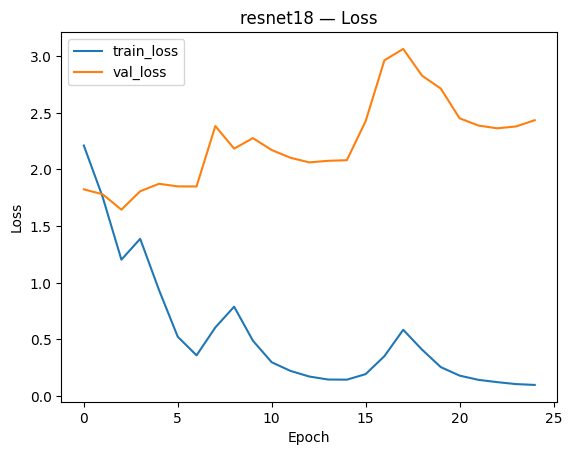

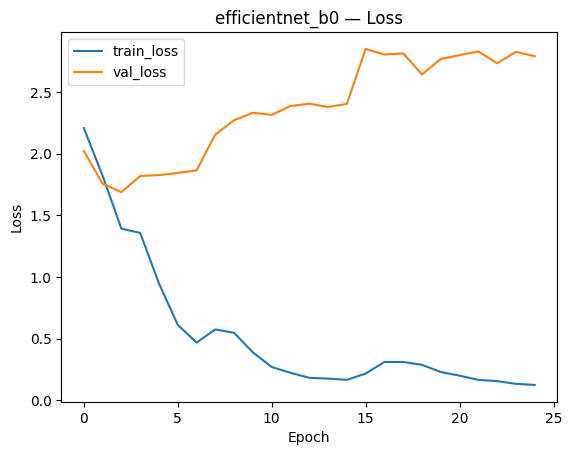

In [16]:
def plot_curves(histories: Dict[str, Dict[str, list]]):
    for mname, h in histories.items():
        plt.figure()
        plt.plot(h["train_loss"], label="train_loss")
        plt.plot(h["val_loss"], label="val_loss")
        plt.title(f"{mname} — Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
        plt.show()

plot_curves(all_histories)

## 9) Final Evaluation & Comparison

In [17]:
rows = []
for mname, ckpt_path in best_paths.items():
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = build_model(mname).to(DEVICE)
    model.load_state_dict(ckpt["model"])
    val_loss, cls_m, reg_m = evaluate(model, dl_val)
    row = {"Model": mname, "val_loss": val_loss} | cls_m | reg_m
    rows.append(row)

df = pd.DataFrame(rows).sort_values("val_loss").reset_index(drop=True)
from IPython.display import display
display(df)

,Model,val_loss,Accuracy,F1_macro,Kappa,AUC_macro_ovr,AUC_PR_macro,RMSE_valence,CORR_valence,CCC_valence,SAGR_valence,RMSE_arousal,CORR_arousal,CCC_arousal,SAGR_arousal,RMSE_mean,CORR_mean,CCC_mean,SAGR_mean
0,resnet18,1.645404,0.49125,0.490471,0.418494,0.855023,0.512940,0.408781,0.547050,0.533573,0.72125,0.340605,0.500765,0.470694,0.80250,0.374693,0.523908,0.502134,0.761875
1,efficientnet_b0,1.687800,0.46500,0.464169,0.387564,0.841733,0.484387,0.397751,0.558014,0.538559,0.72375,0.341800,0.449092,0.424975,0.77125,0.369776,0.503553,0.481767,0.747500


## 10) Qualitative Results (Correct vs Incorrect)

Best baseline: resnet18


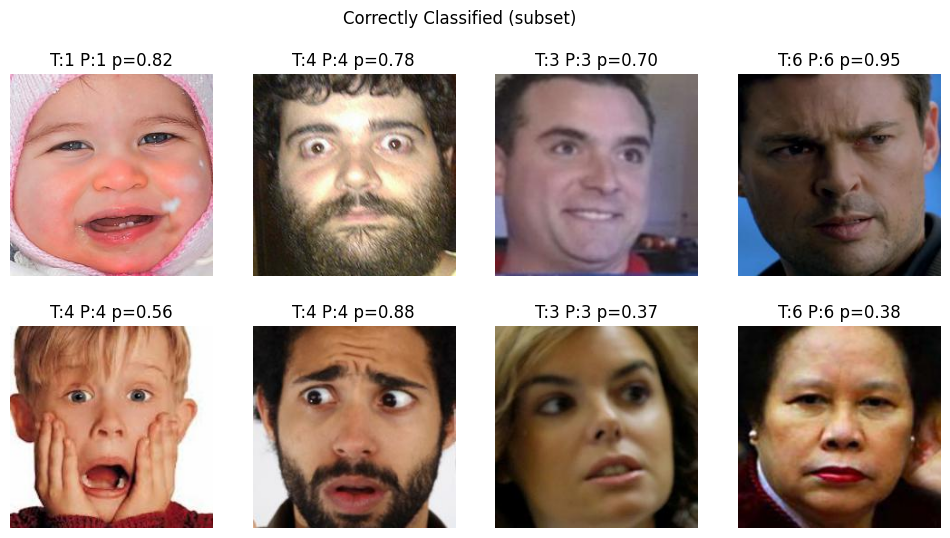

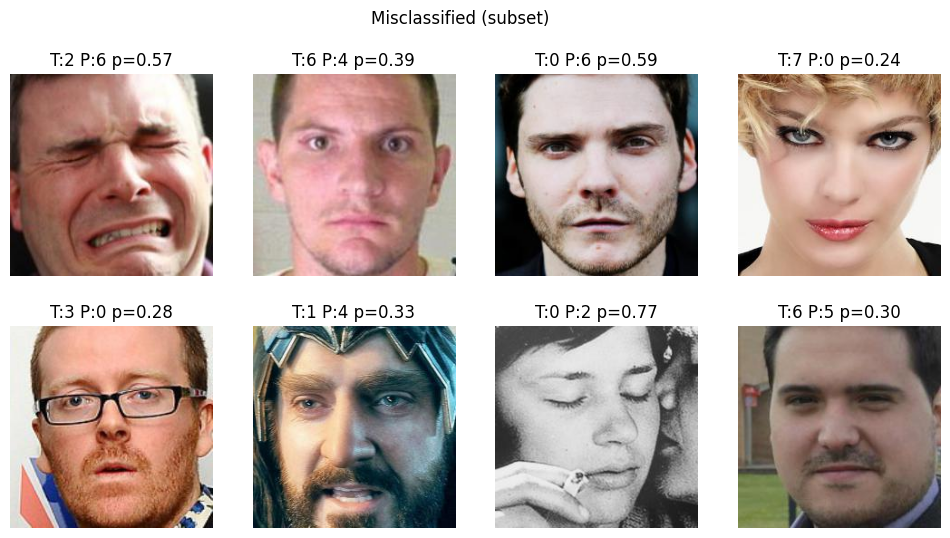

In [18]:
@torch.no_grad()
def collect_predictions(model, loader, max_items=64):
    model.eval()
    out = []
    for x, y_cls, y_reg, paths in loader:
        logits, regs = model(x.to(DEVICE))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        yhat = probs.argmax(1)
        for i in range(len(paths)):
            out.append({
                "path": paths[i],
                "y_true_cls": int(y_cls[i].item()),
                "y_pred_cls": int(yhat[i].item()),
                "prob": float(probs[i, yhat[i]]),
            })
            if len(out) >= max_items:
                return out
    return out

# Use the best model (row 0 in df)
best_name = df.iloc[0]["Model"]
print("Best baseline:", best_name)
ckpt = torch.load(best_paths[best_name], map_location=DEVICE, weights_only=False)
best_model = build_model(best_name).to(DEVICE)
best_model.load_state_dict(ckpt["model"])

preds = collect_predictions(best_model, dl_val, max_items=100)

correct = [p for p in preds if p["y_true_cls"] == p["y_pred_cls"]][:8]
wrong   = [p for p in preds if p["y_true_cls"] != p["y_pred_cls"]][:8]

def show_grid(items, title):
    cols = 4; rows = math.ceil(len(items)/cols)
    plt.figure(figsize=(12, 3*rows))
    for i, it in enumerate(items, 1):
        img = Image.open(it["path"]).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img); plt.axis("off")
        plt.title(f"T:{it['y_true_cls']} P:{it['y_pred_cls']} p={it['prob']:.2f}")
    plt.suptitle(title); plt.show()

show_grid(correct, "Correctly Classified (subset)")
show_grid(wrong,   "Misclassified (subset)")

## 11) Export Key Figures (For Report)

In [19]:
# This section saves comparison CSV and curves to outputs/ for easy inclusion in your short report PDF.
comp_csv = Path(CFG["output_dir"]) / "validation_comparison.csv"
df.to_csv(comp_csv, index=False)
print("Saved comparison to:", comp_csv)

# Save last plotted loss curves per model
for mname, h in all_histories.items():
    fig = plt.figure()
    plt.plot(h["train_loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.title(f"{mname} — Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    fig_path = Path(CFG["output_dir"]) / f"{mname}_loss.png"
    plt.savefig(fig_path, bbox_inches="tight"); plt.close(fig)
    print("Saved:", fig_path)

Saved comparison to: outputs/validation_comparison.csv
Saved: outputs/resnet18_loss.png
Saved: outputs/efficientnet_b0_loss.png


## 12) Appendix — Resume / Inference Helper

In [20]:
def load_best_model(model_name: str, ckpt_path: str):
    model = build_model(model_name).to(DEVICE)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model

# Example:
mdl = load_best_model("resnet18", best_paths["resnet18"])

In [21]:
print(mdl)

Sequential(
  (0): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin